<a href="https://colab.research.google.com/github/Zahraghasemzadeh/rPPG/blob/main/filter_rPPG_aug_cPPg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import resample
from scipy.signal import butter, filtfilt, savgol_filter, detrend
import pywt
import matplotlib.pyplot as plt
import os
from google.colab import drive
import gdown
import zipfile
import shutil

In [2]:
FILE_ID = "16jlBsawf1rOefEaxpSbd_dPspnrZS2nB"
ZIP_PATH = "/content/ppg_arrhythmia.zip"
DATA_PATH = "/content/data"
# ---------------------

# 1. Clean up (from previous runs)
if os.path.exists(DATA_PATH):
    print(f"🧹 Removing existing '{DATA_PATH}' folder...")
    shutil.rmtree(DATA_PATH)

# 2. Download
gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

# 3. Extract
print(f"\n📂 Extracting dataset...")
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall("/content/") # Extract to the parent directory
except zipfile.BadZipFile:
    print(f"❌ Error: Failed to open zip file. Download may have been corrupted.")
    # Stop execution if zip is bad
    raise

# 4. Clean up Zip
print("\n🧹 Deleting zip file...")
os.remove(ZIP_PATH)

# 5. Verify
if os.path.exists(DATA_PATH):
    print(f"\n✅ Success! Dataset is ready in the '{DATA_PATH}' folder.")

    print(f"\n📁 Contents of '{DATA_PATH}' :")
    try:
        # List only the first 5 items
        contents = os.listdir(DATA_PATH)
        print(f"  {contents[:5]} {'...' if len(contents) > 5 else ''}")
    except Exception as e:
        print(f"  Could not list contents: {e}")
else:
    print(f"❌ Error: Final directory '{DATA_PATH}' not found after extraction.")
    print("   Please check the zip file's internal structure.")

Downloading...
From (original): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB
From (redirected): https://drive.google.com/uc?id=16jlBsawf1rOefEaxpSbd_dPspnrZS2nB&confirm=t&uuid=3a3a1a7b-551e-40f2-9a9f-afa29f0b2e94
To: /content/ppg_arrhythmia.zip
100%|██████████| 353M/353M [00:06<00:00, 52.8MB/s]



📂 Extracting dataset...

🧹 Deleting zip file...

✅ Success! Dataset is ready in the '/content/data' folder.

📁 Contents of '/content/data' :
  ['README.md', 'train', 'test'] 


In [3]:
# ==================== LOAD DATASET ====================
train_segments = np.load(os.path.join(DATA_PATH, 'train', 'train_segments.npy'))
train_labels   = np.load(os.path.join(DATA_PATH, 'train', 'train_labels.npy'))
test_segments  = np.load(os.path.join(DATA_PATH, 'test', 'test_segments.npy'))
test_labels    = np.load(os.path.join(DATA_PATH, 'test', 'test_labels.npy'))

# ==================== BASIC STATISTICS ====================
n_train, n_samples = train_segments.shape
n_test = test_segments.shape[0]

print("=" * 60)
print("📊 DATASET SUMMARY")
print("=" * 60)
print(f"✅ Training samples    : {n_train:,}")
print(f"🧪 Test samples        : {n_test:,}")
print(f"📏 Samples per segment : {n_samples:,}")
print(f"💾 Data type           : {train_segments.dtype}")
print()

# ==================== CLASS DISTRIBUTION ====================
train_class_counts = np.bincount(train_labels)
test_class_counts = np.bincount(test_labels)

print("-" * 60)
print("🏷️  LABEL DISTRIBUTION")
print("-" * 60)
print("TRAINING SET:")
print(f"   Class 0 (Healthy)    : {train_class_counts[0]:,} samples ({train_class_counts[0]/n_train*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {train_class_counts[1]:,} samples ({train_class_counts[1]/n_train*100:.1f}%)")
print()
print("TEST SET:")
print(f"   Class 0 (Healthy)    : {test_class_counts[0]:,} samples ({test_class_counts[0]/n_test*100:.1f}%)")
print(f"   Class 1 (Arrhythmic) : {test_class_counts[1]:,} samples ({test_class_counts[1]/n_test*100:.1f}%)")
print()


# ==================== TEMPORAL CHARACTERISTICS ====================
segment_duration_sec = 10.0
sampling_rate = n_samples / segment_duration_sec

train_hours = (n_train * segment_duration_sec) / 3600
test_hours = (n_test * segment_duration_sec) / 3600
total_hours = train_hours + test_hours

print("-" * 60)
print("⏱️  TEMPORAL PROPERTIES")
print("-" * 60)
print(f"   Sampling rate        : {sampling_rate:.1f} Hz")
print(f"   Segment duration     : {segment_duration_sec:.1f} seconds")
print(f"   Training data        : {train_hours:.2f} hours")
print(f"   Test data            : {test_hours:.2f} hours")
print(f"   Total recording time : {total_hours:.2f} hours")
print("=" * 60)

📊 DATASET SUMMARY
✅ Training samples    : 35,120
🧪 Test samples        : 11,707
📏 Samples per segment : 1,000
💾 Data type           : float64

------------------------------------------------------------
🏷️  LABEL DISTRIBUTION
------------------------------------------------------------
TRAINING SET:
   Class 0 (Healthy)    : 10,953 samples (31.2%)
   Class 1 (Arrhythmic) : 24,167 samples (68.8%)

TEST SET:
   Class 0 (Healthy)    : 3,651 samples (31.2%)
   Class 1 (Arrhythmic) : 8,056 samples (68.8%)

------------------------------------------------------------
⏱️  TEMPORAL PROPERTIES
------------------------------------------------------------
   Sampling rate        : 100.0 Hz
   Segment duration     : 10.0 seconds
   Training data        : 97.56 hours
   Test data            : 32.52 hours
   Total recording time : 130.07 hours


## 2️⃣ Dataset Overview & Exploration

### 📋 What You're Working With

You've been provided with **photoplethysmography (PPG) signals** — these are physiological time-series recordings that capture blood volume changes. Your mission: build a model that can distinguish between healthy and arrhythmic heart rhythms!

---

### 📊 DATASET SPECIFICATIONS

|                    | Training | Test   | Total  |
|--------------------|----------|--------|--------|
| **Samples**        | 35,120   | 11,707 | 46,827 |
| **Duration**       | 97.6 hrs | 32.5 hrs | 130.1 hrs |
| **Segment Length** | 10 seconds @ 100 Hz (1,000 samples) |
| **Class Distribution** | Healthy: 31.2% / Arrhythmic: 68.8% |

---

### 🗂️ Dataset Structure
```
data/
├── train/
│   ├── train_segments.npy    # Training PPG signals
│   └── train_labels.npy       # Ground truth labels
└── test/
    ├── test_segments.npy      # Test PPG signals
    └── test_labels.npy        # Test labels
```

### 🏷️ Labels
- **0** = Healthy rhythm (normal cardiac activity)
- **1** = Arrhythmic rhythm (irregular cardiac activity)

---

### Signal Characteristics
- **Sampling rate**: 100 Hz
- **Segment duration**: 10 seconds per sample
- **Data format**: NumPy arrays (.npy)
- **Samples per segment**: 1,000 values

Each sample is a **~10-second PPG segment** stored as a 1-D array. This is a **binary classification** problem — predict the label for each test segment!


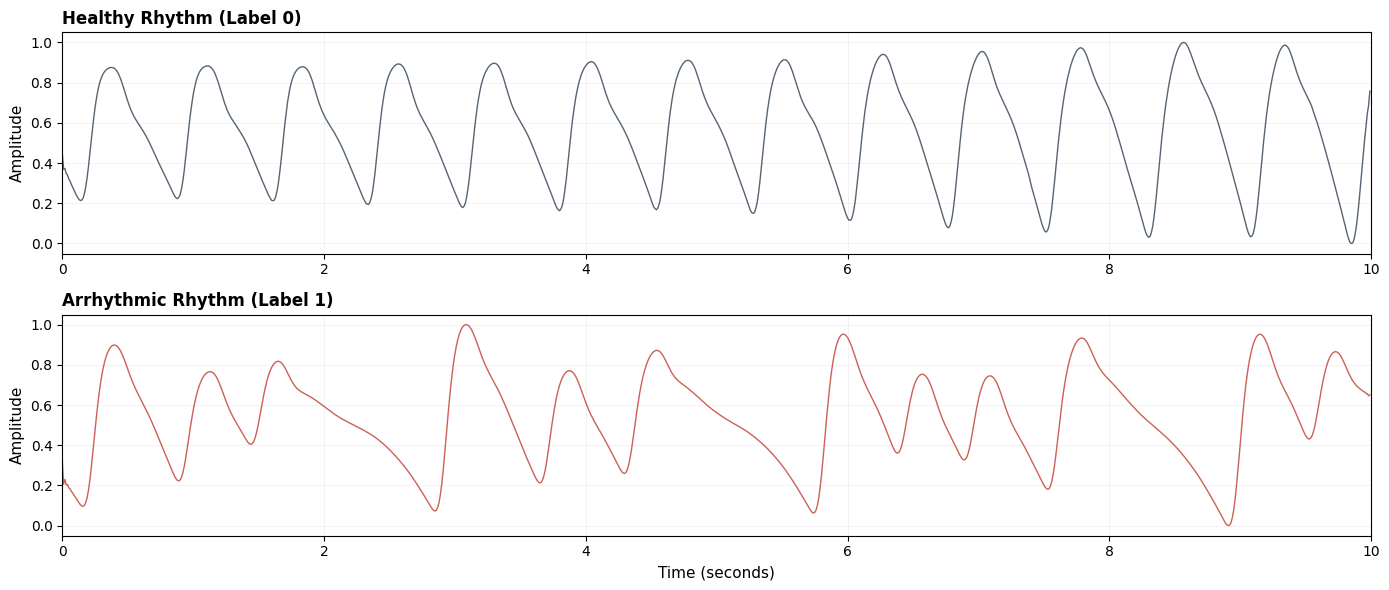

In [4]:
# ==================== SELECT SAMPLE SIGNALS ====================
idx_healthy = np.where(train_labels == 0)[0][1]  # First healthy sample
idx_arr = np.random.choice(np.where(train_labels == 1)[0])  # Random arrhythmic sample

# Calculate time axis in seconds
sampling_rate = 100  # Hz
time_axis = np.arange(n_samples) / sampling_rate

# ==================== PLOT COMPARISON ====================
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='white')

# Healthy rhythm
axes[0].plot(time_axis, train_segments[idx_healthy], linewidth=1, color='#2c3e50', alpha=0.8)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Healthy Rhythm (Label 0)', fontsize=12, loc='left', fontweight='600')
axes[0].grid(True, alpha=0.2, linewidth=0.5)
axes[0].set_xlim(0, 10)

# Arrhythmic rhythm
axes[1].plot(time_axis, train_segments[idx_arr], linewidth=1, color='#c0392b', alpha=0.8)
axes[1].set_xlabel('Time (seconds)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Arrhythmic Rhythm (Label 1)', fontsize=12, loc='left', fontweight='600')
axes[1].grid(True, alpha=0.2, linewidth=0.5)
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

In [68]:
rppg_signal = np.load("rppg_20251108-114228.npy" ) # len = 900

In [69]:
(rppg_signal.shape)

(768,)

In [108]:
rppg_signal = rppg_signal[-600:]

In [109]:
rppg_signal.shape # 2 * 10 s * 30 fps

(600,)

In [110]:
# --- Resample to cPPG length for comparison ---
fs_rppg = 30  # original rPPG recording fps
total_sec = len(rppg_signal)/fs_rppg  # 30 sec
print('sig dur:',total_sec) # 25.6 s
seg_len_sec = 10

num_segments = int(total_sec // seg_len_sec)  # 2
print(num_segments) #3

sig dur: 20.0
2


In [111]:
segments_resampled = []

for i in range(num_segments):
    seg = rppg_signal[i*seg_len_sec*fs_rppg:(i+1)*seg_len_sec*fs_rppg]
    seg_res = resample(seg, 1000)  # resample to match cPPG with fs 100
    segments_resampled.append(seg_res)

In [112]:
len(segments_resampled)

2

In [121]:
segments_resampled = np.stack(segments_resampled, axis=0)  # shape (2, 1000)
one_raw_seg = segments_resampled[1]

## **Denoising**

In [114]:
def bandpass(sig, low, high, fs, order=3):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, sig)

In [115]:
def smooth_signal(signal, window_length=11, polyorder=3):
    return savgol_filter(signal, window_length, polyorder)

In [36]:
def znorm(x):
    x = x - x.mean()
    s = x.std() if x.std() != 0 else 1.0
    return x / s

In [37]:
def preprocess_rppg_segment(seg ):
    seg_bp = bandpass(seg,low = 0.7,high = 3.0 , fs =100)
    seg_sg = smooth_signal(seg_bp, window_length=11, polyorder=3)
    seg_dt = detrend(seg_sg)
    seg_norm = znorm(seg_dt)
    return seg_norm

In [116]:
segments_filtered = np.empty_like(segments_resampled)

for i in range(segments_resampled.shape[0]):
    segments_filtered[i] = preprocess_rppg_segment(segments_resampled[i])


In [117]:
print(segments_filtered.shape)

(2, 1000)


In [118]:
cppg_sample = train_segments[0]
cppg_norm = znorm(cppg_sample)

In [122]:
one_filt_seg = segments_filtered[1]

In [123]:
np.save('final_rppg.npy', one_filt_seg)
np.save('raw_rppg.npy', one_raw_seg)

# with windowing

In [ ]:
signal = segments_filtered          # 1D array, e.g. length 2000
window_size = 1000                   # must match train_segments.shape[1]
step = 1                             # 1 → fully overlapping windows

N = len(signal)
num_windows = N - window_size + 1    # for step = 1

segments_filtered = np.zeros((num_windows, window_size), dtype=np.float32)

for i in range(num_windows):
    window = signal[i : i + window_size]            # shape (1000,)
    window_proc = preprocess_rppg_segment(window)   # expect shape (1000,)
    segments_filtered[i] = window_proc              # put in row i

print(segments_filtered.shape)

In [127]:
one_raw_seg = np.load("raw_rppg.npy" )
one_filt_seg = np.load("final_rppg.npy" )

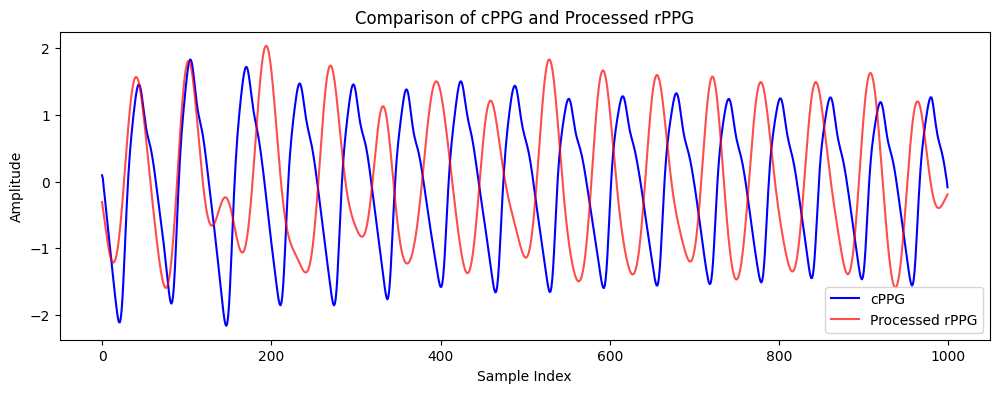

In [125]:
plt.figure(figsize=(12,4))
plt.plot(cppg_norm, label="cPPG", color='blue')
plt.plot(one_filt_seg, label="Processed rPPG", color='red', alpha=0.7)
plt.title("Comparison of cPPG and Processed rPPG")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


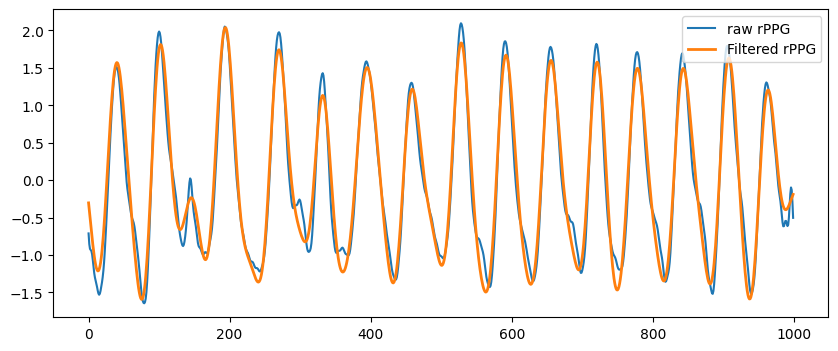

In [128]:
# plot to see effect
plt.figure(figsize=(10,4))
plt.plot(one_raw_seg, label="raw rPPG")
plt.plot(one_filt_seg, label="Filtered rPPG", linewidth=2)
plt.legend()
plt.show()

In [129]:
idx_healthy = np.where(train_labels == 0)[0][1]  # First healthy sample
idx_arr = np.random.choice(np.where(train_labels == 1)[0])  # Random arrhythmic sample

In [130]:
from scipy.signal import welch
from scipy.stats import pearsonr

healthy_idx = np.where(train_labels == 0)[0]
arr_idx     = np.where(train_labels == 1)[0]

X_healthy = train_segments[healthy_idx]
X_arr     = train_segments[arr_idx]
print(len(X_healthy))


10953


In [131]:
# 2) (optional) normalize signals for plotting only (correlation is scale-invariant)
def znorm(x):
    xm = x - np.mean(x)
    s = np.std(xm)
    return xm / (s if s>0 else 1.0)

one_chunk = znorm(one_filt_seg)
raw_norm = znorm(one_raw_seg)

In [132]:
print(one_filt_seg.shape)
print(one_raw_seg.shape)

(1000,)
(1000,)


In [133]:
# 3) compute correlation with every segment (fast loop)
def correlations_with_set(target, matrix):
    corrs = np.empty(matrix.shape[0], dtype=np.float32)
    for i in range(matrix.shape[0]):
        c = matrix[i]
        # pearsonr returns (r, p); use r
        corrs[i] = pearsonr(target, c)[0]
    return corrs

print("Computing correlations (this may take a moment)...")
corrs_healthy = correlations_with_set(one_filt_seg, X_healthy)
corrs_arr     = correlations_with_set(one_filt_seg, X_arr)
raw_corrs_healthy = correlations_with_set(one_raw_seg, X_healthy)
raw_corrs_arr     = correlations_with_set(one_raw_seg, X_arr)

Computing correlations (this may take a moment)...


In [135]:
# 4) summary statistics
def summarize(name, arr):
    print(f"\n{name}: count={len(arr)} mean={np.nanmean(arr):.4f} median={np.nanmedian(arr):.4f} max={np.nanmax(arr):.4f}")

summarize("Healthy correlations after filtering", corrs_healthy)
summarize("Arrhythmia correlations after filtering", corrs_arr)
summarize("raw Healthy correlations", raw_corrs_healthy)
summarize("raw Arrhythmia correlations", raw_corrs_arr)


Healthy correlations after filtering: count=10953 mean=0.0021 median=-0.0032 max=0.7309

Arrhythmia correlations after filtering: count=24167 mean=-0.0002 median=-0.0013 max=0.7218

raw Healthy correlations: count=10953 mean=0.0020 median=-0.0028 max=0.7168

raw Arrhythmia correlations: count=24167 mean=-0.0002 median=-0.0021 max=0.7080


In [137]:
# 5) find best matches
top_k = 5
h_top_idx = np.argsort(corrs_healthy)[-top_k:][::-1]  # descending
a_top_idx = np.argsort(corrs_arr)[-top_k:][::-1]

print("\nTop healthy matches (index in healthy subset, correlation):")
for idx in h_top_idx:
    print(idx, f"{corrs_healthy[idx]:.4f}")

print("\nTop arrhythmia matches (index in arr subset, correlation):")
for idx in a_top_idx:
    print(idx, f"{corrs_arr[idx]:.4f}")




Top healthy matches (index in healthy subset, correlation):
8563 0.7309
1502 0.7111
383 0.6709
9913 0.6660
3814 0.6609

Top arrhythmia matches (index in arr subset, correlation):
6872 0.7218
12982 0.6569
3453 0.6437
23286 0.6395
15895 0.6222


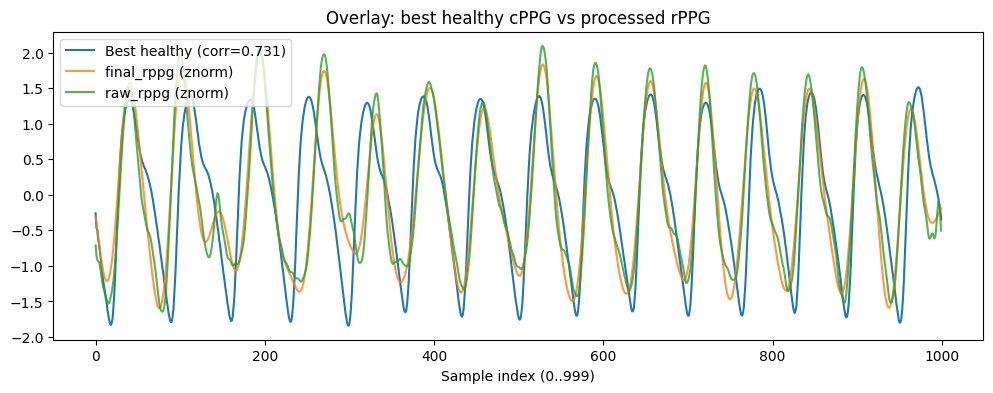

In [138]:
# 6) plot best healthy match vs rPPG (overlay)
best_h_idx = h_top_idx[0]
best_h_seg = X_healthy[best_h_idx]

plt.figure(figsize=(12,4))
plt.plot(znorm(best_h_seg), label=f"Best healthy (corr={corrs_healthy[best_h_idx]:.3f})")
plt.plot(one_filt_seg, label="final_rppg (znorm)", alpha=0.8)
plt.plot(one_raw_seg, label="raw_rppg (znorm)", alpha=0.8)
plt.title("Overlay: best healthy cPPG vs processed rPPG")
plt.xlabel("Sample index (0..999)")
plt.legend()
plt.show()

In [139]:
# 7) simple HR estimate via PSD peak in band 0.7-4 Hz
def estimate_hr(signal, fs=100.0, fmin=0.7, fmax=4.0):
    f, P = welch(signal, fs=fs, nperseg=256)
    # restrict band
    mask = (f >= fmin) & (f <= fmax)
    if not np.any(mask):
        return np.nan
    f_band = f[mask]; P_band = P[mask]
    peak_f = f_band[np.argmax(P_band)]
    hr_bpm = peak_f * 60.0
    return hr_bpm

hr_rppg = estimate_hr(one_chunk, fs=100.0)   # final_rppg is length 1000 -> 100 Hz equivalent
hr_best_h = estimate_hr(best_h_seg, fs=100.0)

print(f"\nEstimated HR (rPPG): {hr_rppg:.2f} bpm")
print(f"Estimated HR (best healthy match): {hr_best_h:.2f} bpm")



Estimated HR (rPPG): 93.75 bpm
Estimated HR (best healthy match): 93.75 bpm
